In [8]:
#미국 의대생의 입학관련 데이터셋
# Acceptance: 0이면 불합격, 1이면 합격
# BCPM: Bio/Chem/Physics/Math 과목의 학점 평균
# GPA: 전체과목 학점 평균
# VR: MCAT Verbal reasoning 과목 점수
# PS: MCAT Physical sciences 과목 점수
# WS: MCAT Writing sample 과목 점수
# BS: MCAT Biological sciences 과목 점수
# MCAT: MCAT 총점
# Apps: 의대 지원 횟수
import statsmodels.api as sm

data_med = sm.datasets.get_rdataset('MedGPA', package='Stat2Data')
df_med = data_med.data
df_med.tail()

,Accept,Acceptance,Sex,BCPM,GPA,VR,PS,WS,BS,MCAT,Apps
50,D,0,M,2.41,2.72,8,8,8.0,8,32,7
51,D,0,M,3.51,3.56,11,8,6.0,9,34,6
52,A,1,F,3.43,3.48,7,10,7.0,10,34,14
53,D,0,M,2.61,2.80,7,5,NaN,6,18,6
54,D,0,M,3.36,3.44,11,11,8.0,9,39,1


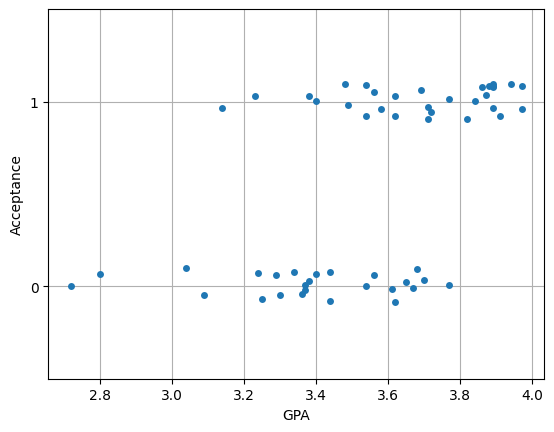

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# 학점과 합격여부의 상관관계
#  jitter=True(데이터의 수가 많을 경우 겹치지 않도록 하는 옵션)
sns.stripplot(x="GPA", y="Acceptance", data=df_med, jitter=True, orient='h', order=[1,0])
plt.grid(True)
plt.show()

In [12]:
#MCAT = VR + PS + WS + BS이므로 MCAT는 독립변수에서 제외
model_med = sm.Logit.from_formula("Acceptance ~ Sex + BCPM + GPA + VR + PS + WS + BS + Apps", df_med)
result_med = model_med.fit()
result_med.summary()

Optimization terminated successfully.
         Current function value: 0.280736
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             Acceptance   No. Observations:                   54
Model:                          Logit   Df Residuals:                       45
Method:                           MLE   Df Model:                            8
Date:                Thu, 22 Jan 2026   Pseudo R-squ.:                  0.5913
Time:                        10:57:55   Log-Likelihood:                -15.160
converged:                       True   LL-Null:                       -37.096
Covariance Type:            nonrobust   LLR p-value:                 6.014e-07
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -46.6414     15.600     -2.990      0.003     -77.216     -16.067
Sex[T.M]      -2.2835      1.429     -1.597      0.110      -5.085       0.518
BCPM          -6.1633      6.963     -0.885      0.376     -19.811       7.484
GPA           12.3973      8.611      1.440      0.150      -4.479      29.274
VR             0.0790      0.311      0.254      0.799      -0.530       0.688
PS             1.1673      0.539      2.164      0.030       0.110       2.225
WS            -0.7784      0.396     -1.968      0.049      -1.554      -0.003
BS             1.9184      0.682      2.814      0.005       0.582       3.255
Apps           0.0512      0.147      0.348      0.728      -0.237       0.340
==============================================================================
"""

In [ ]:
# Pseudo R-squ.: 0.5913 모형의 설명력 59%
# coef(기울기) => GPA가 1 상승하면 합격율이 12.39 상승한다
# P>|z|(유의확률) <0.05 유의함 (PS, WS, BS)